# OSM Floorplan Decomposition

### Configure notebook environment
Set project paths and import the reusable OSM helpers used by the decomposition workflow.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shapely.geometry import MultiPolygon, Polygon
from shapely.geometry.base import BaseGeometry


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / '.git').exists() and (path / 'notebooks').exists():
            return path
    raise FileNotFoundError('Could not locate the ConvexDecomp project root.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
SUBSET_BUILDINGS_PATH = INTERIM_DIR / 'subset_buildings_gdf.pkl'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.helpers.GHSL_gridplot import GHSL_gridplot
from notebooks.helpers.convex_decomposition import AdaptiveSearchConfig
from notebooks.helpers.osm_convex_decomposer import (
    ConvexDecompositionConfig,
    decompose_polygon_with_stats,
    extract_polygons,
)
from notebooks.helpers.osm_perimeter_builder import (
    PerimeterConfig,
    build_perimeter_zones_for_gdf,
    summarize_perimeter_results,
)
from notebooks.helpers.osm_perimeter_subdivider import (
    PerimeterSubdivisionConfig,
    subdivide_perimeter_gdf,
)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 10


### Load the preprocessed OSM subset and inspect input diagnostics

**Inputs**
- `data/interim/subset_buildings_gdf.pkl` from `OSM_Preprocessing.ipynb`
- Shared helper `notebooks.helpers.floorplan_dataset_diagnostics`

**Steps**
1. Load the OSM working subset used by the rest of the notebook.
2. Report how many input polygons the subset contains and how many are already concave.
3. Count how many samples contain at least one polygon below `2.0 m^2`.
4. Plot a compact row of input-distribution diagnostics before perimeter preprocessing and convex decomposition.

**Outputs**
- `subset_buildings_gdf`
- Printed input-dataset diagnostics and a diagnostic plot row

subset_buildings_gdf shape: (2756, 6)
columns: ['sample_id', 'geometry', 'area_m2', 'n_vertices', 'n_holes', 'complexity_class']

=== OSM input diagnostics ===
Samples in working set: 2756
Polygons across all samples: 2756
Concave polygons before convex decomposition: 2756 / 2756 (100.0%)
Samples with at least one polygon below 2.0 m^2: 0 / 2756 (0.0%)


,sample_id,geometry,area_m2,n_vertices,n_holes,complexity_class
0,Pecs_256360633,"POLYGON ((-6.627 4.618, 4.783 5.081, 4.907 1.2...",119.796641,6,0,A
1,Burton_Latimer_1054357481,"POLYGON ((3.792 -5.048, -2.63 -5.282, -3.3 6.2...",64.692547,6,0,A
2,Chemnitz_99511238,"POLYGON ((4.677 12.44, 10.742 -6.895, -5.687 -...",327.971364,6,0,A
3,Drobeta_Turnu_Severin_290306508,"POLYGON ((7.559 -5.815, -3.971 -9.346, -6.681 ...",178.764982,6,0,A
4,Mechelen_331861832,"POLYGON ((-7.317 7.897, 6.519 0.682, 5.07 -1.6...",130.769929,6,0,A


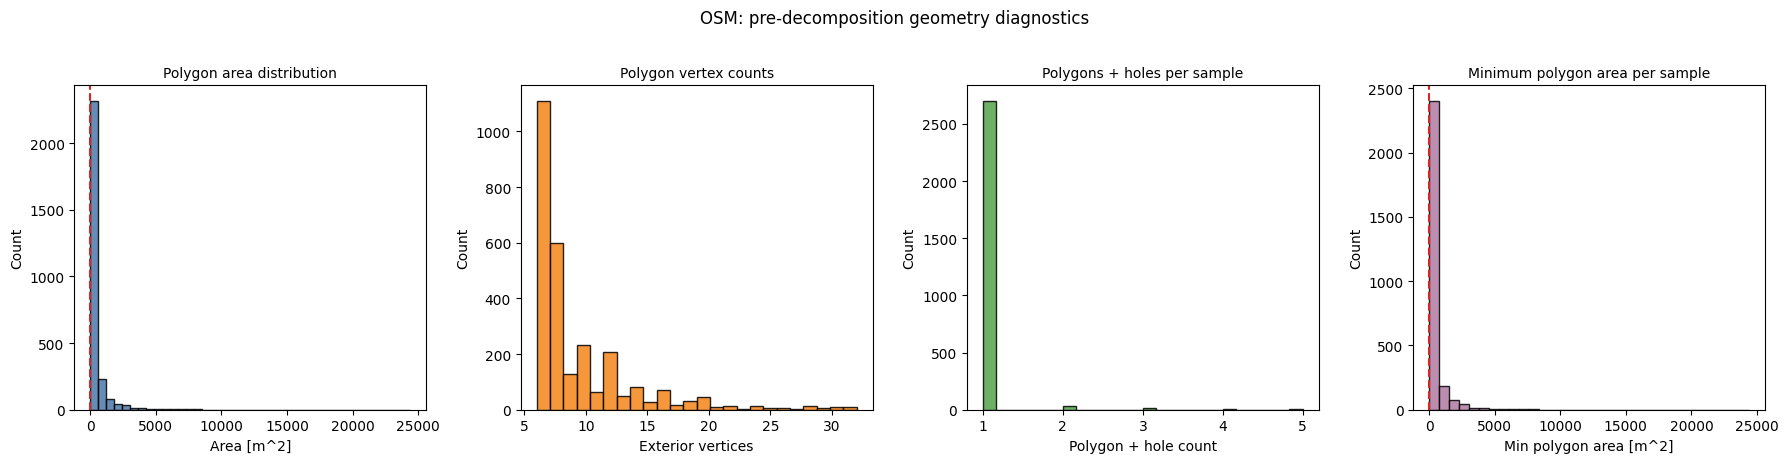

In [2]:
if not SUBSET_BUILDINGS_PATH.exists():
    raise FileNotFoundError(
        f'Missing {SUBSET_BUILDINGS_PATH}. Run OSM_Preprocessing.ipynb first to create the preprocessed subset.'
    )

subset_buildings_gdf = pd.read_pickle(SUBSET_BUILDINGS_PATH)

from notebooks.helpers.floorplan_dataset_diagnostics import (
    plot_osm_input_dataset_diagnostics,
)

print('subset_buildings_gdf shape:', subset_buildings_gdf.shape)
print('columns:', subset_buildings_gdf.columns.tolist())
print('')
input_diag_summary, input_diag_df = plot_osm_input_dataset_diagnostics(
    subset_buildings_gdf,
    polygons_col='geometry',
    sample_id_col='sample_id',
    min_area_m2=2.0,
    dataset_label='OSM',
)
subset_buildings_gdf.head()


### Configure perimeter zoning parameters
Keep the OSM perimeter builder aligned with the current probe-based interior rule used in the active helper module.


In [3]:
PERIMETER_CFG = PerimeterConfig(
    perimeter_depth_m=4.5,
    min_zone_edge_m=2.0,
    min_zone_area_m2=4.0,
    min_interior_edge_m=2.0,
    min_interior_area_m2=4.0,
    min_input_area_m2=2.0,
    interior_probe_offset_m=0.5,
    simplify_tolerance_m=0.001,
    min_contact_groups=2,
    min_contact_group_length_m=0.5,
    contact_turn_angle_deg=35.0,
    enforce_input_edge_threshold=False,
)

PERIMETER_CFG


PerimeterConfig(perimeter_depth_m=4.5, min_zone_edge_m=2.0, min_zone_area_m2=4.0, min_interior_edge_m=2.0, min_interior_area_m2=4.0, interior_opening_m=0.5, interior_simplify_tolerance_m=0.0, min_input_area_m2=2.0, interior_probe_offset_m=0.5, interior_min_edge_cleanup_m=0.1, simplify_tolerance_m=0.001, eps_m=0.01, min_contact_groups=2, min_contact_group_length_m=0.5, contact_turn_angle_deg=35.0, enforce_input_edge_threshold=False, split_perimeter_holes=True, area_tol=1e-06, join_style=2, offset_match_angle_tol_deg=5.0, offset_match_distance_tol_m=0.5)

### Build perimeter zoning results and inspect successful split cases

**Inputs**
- `subset_buildings_gdf` with the working OSM sample in `geometry`
- `PERIMETER_CFG` with the perimeter depth, probe offset, and interior-validity thresholds

**Steps**
1. Run the module-backed perimeter zoning pipeline on every building footprint.
2. Store the returned `perimeter_geom`, `interior_geom`, exact offset matches, and diagnostics on `subset_buildings_gdf`.
3. Summarize how many buildings end up as `perimeter + interior`, `perimeter only`, or `no perimeter zoning`.
4. Plot a compact count summary and the detailed reason breakdown.
5. Use `GHSL_gridplot` to overlay original footprints, perimeter shells, and retained interior cores for a small sample of successful split cases.

**Outputs**
- Updated `subset_buildings_gdf` with perimeter zoning columns
- `perimeter_summary` with aggregate counts and reason frequencies
- Gridplots for buildings where a split perimeter/core zoning was retained

**Used functions**
`build_perimeter_zones_for_gdf`, `summarize_perimeter_results`, `GHSL_gridplot`


Perimeter zoning summary:
Total buildings: 2756
Perimeter + interior: 1266
Perimeter only: 1490
No perimeter zoning: 0

Reason counts:
perimeter_with_interior                  1266
perimeter_only_no_nominal_interior       1199
perimeter_only_all_interiors_absorbed     291


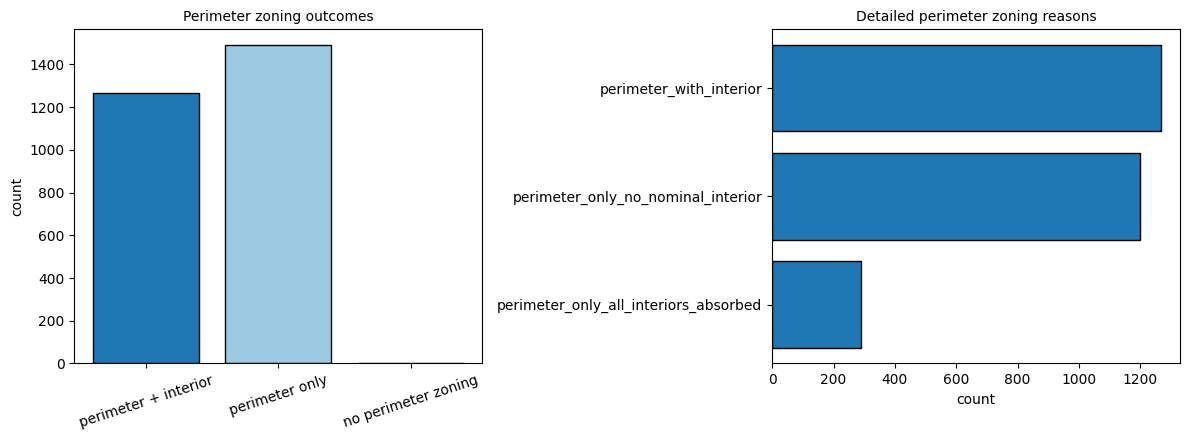

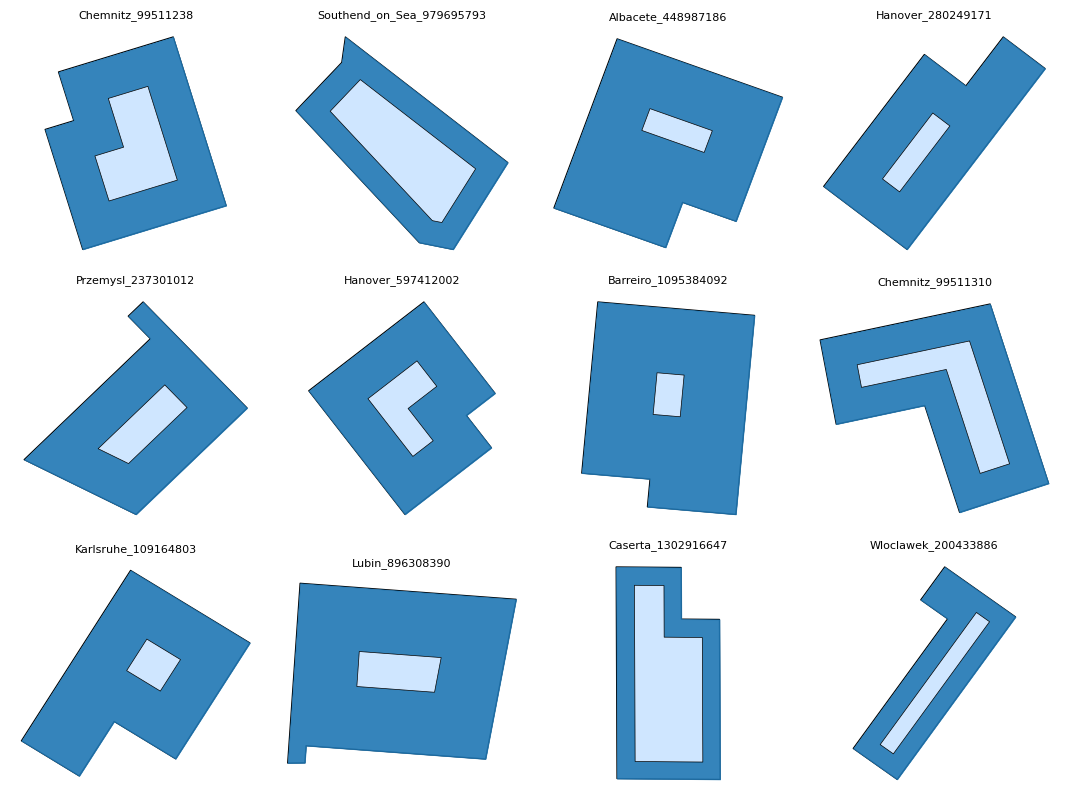

In [4]:
N_SHOW_PERIM = 12

subset_buildings_gdf = build_perimeter_zones_for_gdf(
    subset_buildings_gdf,
    geometry_col='geometry',
    cfg=PERIMETER_CFG,
)
perimeter_summary = summarize_perimeter_results(subset_buildings_gdf)

print('Perimeter zoning summary:')
print(f"Total buildings: {perimeter_summary['n_total']}")
print(f"Perimeter + interior: {perimeter_summary['n_with_interior']}")
print(f"Perimeter only: {perimeter_summary['n_perimeter_only']}")
print(f"No perimeter zoning: {perimeter_summary['n_no_perimeter_defined']}")
print('')
print('Reason counts:')
print(pd.Series(perimeter_summary['reason_counts']).to_string())

summary_plot_df = pd.DataFrame(
    {
        'category': ['perimeter + interior', 'perimeter only', 'no perimeter zoning'],
        'count': [
            perimeter_summary['n_with_interior'],
            perimeter_summary['n_perimeter_only'],
            perimeter_summary['n_no_perimeter_defined'],
        ],
    }
)
reason_plot = pd.Series(perimeter_summary['reason_counts']).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(summary_plot_df['category'], summary_plot_df['count'], color=['#1f77b4', '#9ecae1', '#d9d9d9'], edgecolor='black')
axes[0].set_title('Perimeter zoning outcomes')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=18)

axes[1].barh(reason_plot.index, reason_plot.values, color='#1f77b4', edgecolor='black')
axes[1].set_title('Detailed perimeter zoning reasons')
axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()

perim_ids = (
    subset_buildings_gdf.loc[subset_buildings_gdf['perimeter'], 'sample_id']
    .dropna()
    .head(N_SHOW_PERIM)
    .tolist()
)

if not perim_ids:
    print('No buildings retained a split perimeter + interior zoning under the current configuration.')
else:
    bsub = subset_buildings_gdf.loc[subset_buildings_gdf['sample_id'].isin(perim_ids)].copy()
    bsub_outline = gpd.GeoDataFrame(bsub, geometry='geometry', crs=subset_buildings_gdf.crs)
    bsub_perimeter = gpd.GeoDataFrame(bsub, geometry='perimeter_geom', crs=subset_buildings_gdf.crs)
    bsub_interior = gpd.GeoDataFrame(
        bsub.loc[bsub['interior_geom'].notna()].copy(),
        geometry='interior_geom',
        crs=subset_buildings_gdf.crs,
    )

    GHSL_gridplot(
        [
            {
                'name': 'building_outline',
                'gdf': bsub_outline,
                'role': 'main',
                'id_col': 'sample_id',
                'geometry_col': 'geometry',
                'color': 'none',
                'edgecolor': 'black',
                'linewidth': 0.9,
                'zorder': 1,
            },
            {
                'name': 'perimeter_geom',
                'gdf': bsub_perimeter,
                'role': 'main',
                'id_col': 'sample_id',
                'geometry_col': 'perimeter_geom',
                'color': '#1f77b4',
                'edgecolor': '#1f77b4',
                'linewidth': 0.5,
                'alpha': 0.9,
                'zorder': 2,
            },
            {
                'name': 'interior_geom',
                'gdf': bsub_interior,
                'role': 'main',
                'id_col': 'sample_id',
                'geometry_col': 'interior_geom',
                'color': '#cfe6ff',
                'edgecolor': 'black',
                'linewidth': 0.5,
                'alpha': 1.0,
                'zorder': 3,
            },
        ],
        ids=perim_ids,
        ncols=4,
        figsize_scale=2.7,
        title_fn=lambda sid, i: str(sid),
    )


## Prepare convex decomposition inputs


### Configure optional trapezoid-triangle pre-check
Set `USE_TRAPEZOID_TRIANGLE_PRECHECK=True` to extract matched trapezoids and corner triangles from perimeter zones before the general convex decomposition runs.


In [5]:
USE_TRAPEZOID_TRIANGLE_PRECHECK = True

PRECHECK_SUBDIV_CFG = PerimeterSubdivisionConfig(
    min_trapezoid_area_m2=4.0,
    simplify_tolerance_m=0.001,
)

{
    'USE_TRAPEZOID_TRIANGLE_PRECHECK': USE_TRAPEZOID_TRIANGLE_PRECHECK,
    'PRECHECK_SUBDIV_CFG': PRECHECK_SUBDIV_CFG,
}


{'USE_TRAPEZOID_TRIANGLE_PRECHECK': True,
 'PRECHECK_SUBDIV_CFG': PerimeterSubdivisionConfig(min_trapezoid_area_m2=4.0, simplify_tolerance_m=0.001)}

### Prepare polygon inputs for decomposition

**Inputs**
- `subset_buildings_gdf` after perimeter zoning
- `USE_TRAPEZOID_TRIANGLE_PRECHECK` and `PRECHECK_SUBDIV_CFG`

**Steps**
1. Build the default polygon list for each building from `perimeter_parts + interior_geom`, or the original footprint when no perimeter zoning exists.
2. Optionally run `subdivide_perimeter_gdf` to extract matched trapezoids, corner triangles, and leftover perimeter remainders before decomposition.
3. Store the final per-building polygon list in `decomp_polygons` and summarize the resulting polygon and vertex counts.

**Outputs**
- `buildings_convex_gdf` with prepared `decomp_polygons`
- Optional `trapezoid_seed_gdf`, `corner_seed_gdf`, and `remainder_seed_gdf`

**Used functions**
`subdivide_perimeter_gdf`, `extract_polygons`


In [6]:
def collect_building_polygons(row: pd.Series) -> list[Polygon]:
    if bool(row.get('perimeter_defined', False)):
        polys = []
        polys.extend(extract_polygons(row.get('perimeter_parts')))
        polys.extend(extract_polygons(row.get('interior_geom')))
        return polys
    return extract_polygons(row.get('geometry'))


def count_polygon_vertices(polygons: list[Polygon]) -> int:
    total = 0
    for poly in polygons:
        try:
            total += max(0, len(list(poly.exterior.coords)) - 1)
        except Exception:
            pass
    return total


def group_seed_parts(parts_gdf: gpd.GeoDataFrame, *, id_col: str = 'sample_id') -> dict[str, list[Polygon]]:
    grouped: dict[str, list[Polygon]] = {}
    if parts_gdf is None or parts_gdf.empty:
        return grouped
    for sample_id, group in parts_gdf.groupby(id_col):
        grouped[sample_id] = [
            geom for geom in group.geometry
            if geom is not None and not getattr(geom, 'is_empty', True)
        ]
    return grouped


buildings_convex_gdf = subset_buildings_gdf.copy()

if USE_TRAPEZOID_TRIANGLE_PRECHECK:
    buildings_convex_gdf, trapezoid_seed_gdf, corner_seed_gdf, remainder_seed_gdf = subdivide_perimeter_gdf(
        buildings_convex_gdf,
        id_col='sample_id',
        cfg=PRECHECK_SUBDIV_CFG,
    )
    trapezoid_seed_map = group_seed_parts(trapezoid_seed_gdf)
    corner_seed_map = group_seed_parts(corner_seed_gdf)
    remainder_seed_map = group_seed_parts(remainder_seed_gdf)
else:
    empty_geometry = gpd.GeoDataFrame({'geometry': []}, geometry='geometry', crs=buildings_convex_gdf.crs)
    trapezoid_seed_gdf = empty_geometry.copy()
    corner_seed_gdf = empty_geometry.copy()
    remainder_seed_gdf = empty_geometry.copy()
    trapezoid_seed_map = {}
    corner_seed_map = {}
    remainder_seed_map = {}


def collect_decomposition_polygons(row: pd.Series) -> list[Polygon]:
    if not USE_TRAPEZOID_TRIANGLE_PRECHECK:
        return collect_building_polygons(row)

    if bool(row.get('perimeter_defined', False)):
        sample_id = row['sample_id']
        polygons = []
        polygons.extend(trapezoid_seed_map.get(sample_id, []))
        polygons.extend(corner_seed_map.get(sample_id, []))
        polygons.extend(remainder_seed_map.get(sample_id, []))
        polygons.extend(extract_polygons(row.get('interior_geom')))
        return polygons

    return extract_polygons(row.get('geometry'))


buildings_convex_gdf['decomp_polygons'] = buildings_convex_gdf.apply(collect_decomposition_polygons, axis=1)
buildings_convex_gdf['n_polygons'] = buildings_convex_gdf['decomp_polygons'].apply(len)
buildings_convex_gdf['n_vertices'] = buildings_convex_gdf['decomp_polygons'].apply(count_polygon_vertices)

print('Buildings prepared for decomposition:', len(buildings_convex_gdf))
print('Perimeter-defined buildings:', int(buildings_convex_gdf['perimeter_defined'].fillna(False).sum()))
print('Split perimeter + interior buildings:', int(buildings_convex_gdf['perimeter'].fillna(False).sum()))
print('Perimeter-only buildings:', int(buildings_convex_gdf['perimeter_only'].fillna(False).sum()))
print('No perimeter zoning buildings:', int((~buildings_convex_gdf['perimeter_defined'].fillna(False)).sum()))
print(f"Mean decomposition input polygons per building: {buildings_convex_gdf['n_polygons'].mean():.2f}")
print(f"Mean decomposition input vertices per building: {buildings_convex_gdf['n_vertices'].mean():.2f}")

if USE_TRAPEZOID_TRIANGLE_PRECHECK:
    print('')
    print('Perimeter pre-check summary:')
    print(f'Trapezoid seeds: {len(trapezoid_seed_gdf)}')
    print(f'Corner-triangle seeds: {len(corner_seed_gdf)}')
    print(f'Remainder perimeter seeds: {len(remainder_seed_gdf)}')
    print(buildings_convex_gdf['trapezoid_subdivision_reason'].fillna('missing').value_counts().to_string())
else:
    print('')
    print('Perimeter pre-check summary: disabled (direct decomposition of perimeter parts and interiors).')


Buildings prepared for decomposition: 2756
Perimeter-defined buildings: 2756
Split perimeter + interior buildings: 1266
Perimeter-only buildings: 1490
No perimeter zoning buildings: 0
Mean decomposition input polygons per building: 3.27
Mean decomposition input vertices per building: 20.18

Perimeter pre-check summary:
Trapezoid seeds: 4693
Corner-triangle seeds: 156
Remainder perimeter seeds: 2773
trapezoid_subdivision_reason
insufficient_exact_vertex_matches               1199
matched_trapezoids                              1064
discarded_small_interior_kept_as_single_zone     243
insufficient_consecutive_matches                 118
matched_trapezoids_and_corners                    98
collapsed_corner_parts                            34


### Configure the convex decomposer
Set the polygon-wise decomposer parameters and adaptive retry schedule used on the prepared decomposition inputs.


In [7]:
cfg = ConvexDecompositionConfig(
    search_depth=24,
    search_width=4,
    max_reflex_per_node=8,
    max_variants_per_polygon=32,
    max_failed_states=500,
    track_time=True,
    min_area_m2=2.0,
    weight_parts=1.0,
    weight_compactness=20.0,
    adaptive_search=AdaptiveSearchConfig(
        enabled=True,
        initial_depth=4,
        initial_width=3,
        max_depth=24,
        max_width=4,
        depth_step=1,
        width_step=1,
    ),
)

cfg


ConvexDecompositionConfig(search_depth=24, search_width=4, max_variants_per_polygon=32, max_failed_states=500, min_area_m2=2.0, weight_parts=1.0, weight_compactness=20.0, min_concavity_deg=2.0, max_reflex_per_node=8, length_factor=10.0, track_time=True, use_bisector_dead_end_fallback=True, cut_snap_vertex_tolerance_m=0.1, adaptive_search=AdaptiveSearchConfig(enabled=True, initial_depth=4, initial_width=3, max_depth=24, max_width=4, depth_step=1, width_step=1))

## Run convex decomposition

**Inputs**
- `buildings_convex_gdf` with `decomp_polygons`, `n_polygons`, and `n_vertices`
- `cfg` with the convex decomposition search depth, width, adaptive retry schedule, and scoring weights

**Steps**
1. Read the prepared polygon list for each building from `decomp_polygons`.
2. Run `decompose_polygon_with_stats` on each polygon, starting from a cheap search setting and retrying with larger depth, then width, until the first successful parameter setting is found.
3. Collect the returned convex pieces, timings, retry diagnostics, and success flags back to building level.
4. Store the merged convex output geometry in `convex_parts_geom` for later summaries and plots.

**Outputs**
- `buildings_convex_gdf` enriched with per-building convex decomposition results
- `results_df` with counts, flags, timings, retry diagnostics, and output geometries

**Used functions**
`decompose_polygon_with_stats`


In [8]:
def build_parts_geometry(parts: list[Polygon]) -> BaseGeometry | None:
    if not parts:
        return None
    if len(parts) == 1:
        return parts[0]
    return MultiPolygon(parts)


def sum_time_list(values: list[float | None] | None) -> float:
    if not isinstance(values, (list, tuple)):
        return 0.0
    clean_values = []
    for value in values:
        if value is None:
            continue
        try:
            clean_values.append(float(value))
        except (TypeError, ValueError):
            continue
    return float(np.nansum(clean_values)) if clean_values else 0.0


def min_part_area(parts: list[Polygon]) -> float:
    areas = []
    for part in parts or []:
        if part is None or getattr(part, 'is_empty', True):
            continue
        try:
            areas.append(float(part.area))
        except Exception:
            continue
    return float(min(areas)) if areas else float('nan')


results = []
polygon_rows = []

for idx, row in buildings_convex_gdf.iterrows():
    polygons = row.get('decomp_polygons') or []
    if not polygons:
        results.append({
            'index': idx,
            'convex_decomp_success': False,
            'convex_variants_total': 0,
            'convex_parts_counts': [],
            'polygon_fully_convex_flags': [],
            'building_fully_convex': False,
            'building_decomposition_failed': False,
            'n_successful_polygons': 0,
            'building_has_small_zone': False,
            'convex_parts_geom': None,
            'polygon_times_seconds': [],
            'polygon_fallbacks': [],
            'polygon_search_terminated_by': [],
            'polygon_search_depths_used': [],
            'polygon_search_widths_used': [],
            'polygon_search_attempt_counts': [],
            'n_failed_polygons': 0,
            'n_small_zone_polygons': 0,
            'n_retried_polygons': 0,
            'total_search_attempts': 0,
            'max_search_depth_used': 0,
            'max_search_width_used': 0,
            'time_total_seconds': 0.0,
        })
        continue

    convex_parts = []
    convex_parts_counts = []
    polygon_flags = []
    polygon_times = []
    polygon_fallbacks = []
    polygon_stop_reasons = []
    polygon_search_depths = []
    polygon_search_widths = []
    polygon_search_attempt_counts = []
    convex_variants_total = 0
    building_has_small_zone = False
    n_failed_polygons = 0
    n_small_zone_polygons = 0

    for polygon_idx, polygon in enumerate(polygons, start=1):
        stats = decompose_polygon_with_stats(polygon, cfg)
        convex_variants_total += int(stats['n_variants'])
        convex_parts_counts.append(int(stats['n_parts']))
        polygon_flags.append(bool(stats['fully_convex_best']))
        polygon_times.append(stats.get('time_seconds'))
        polygon_fallbacks.append(stats.get('fallback_used'))
        polygon_stop_reasons.append(stats.get('search_terminated_by'))
        polygon_search_depths.append(stats.get('search_depth_used'))
        polygon_search_widths.append(stats.get('search_width_used'))
        polygon_search_attempt_counts.append(int(stats.get('search_attempt_count', 0) or 0))
        building_has_small_zone = building_has_small_zone or bool(stats['has_small_zone'])
        n_failed_polygons += int(not bool(stats['fully_convex_best']))
        n_small_zone_polygons += int(bool(stats['has_small_zone']))
        convex_parts.extend(stats['best_variant'])

        polygon_rows.append({
            'index': idx,
            'sample_id': row['sample_id'],
            'polygon_idx': polygon_idx,
            'zone_id': f"{row['sample_id']}_poly_{polygon_idx:02d}",
            'fully_convex_best': bool(stats['fully_convex_best']),
            'has_small_zone': bool(stats['has_small_zone']),
            'n_variants': int(stats['n_variants']),
            'n_parts': int(stats['n_parts']),
            'search_terminated_by': stats.get('search_terminated_by'),
            'n_failed_terminal_states': int(stats.get('n_failed_terminal_states', 0) or 0),
            'n_depth_limit_dead_ends': int(stats.get('n_depth_limit_dead_ends', 0) or 0),
            'n_no_reflex_dead_ends': int(stats.get('n_no_reflex_dead_ends', 0) or 0),
            'n_min_area_dead_ends': int(stats.get('n_min_area_dead_ends', 0) or 0),
            'n_states_seen': int(stats.get('n_states_seen', 0) or 0),
            'search_depth_used': stats.get('search_depth_used'),
            'search_width_used': stats.get('search_width_used'),
            'search_attempt_count': int(stats.get('search_attempt_count', 0) or 0),
            'search_attempt_history': list(stats.get('search_attempt_history') or []),
            'fallback_used': stats.get('fallback_used'),
            'polygon_time_seconds': stats.get('time_seconds'),
            'best_min_part_area_m2': min_part_area(stats['best_variant']),
            'geometry': polygon,
            'building_geometry': row['geometry'],
            'best_variant_geom': build_parts_geometry(stats['best_variant']),
        })

    building_fully_convex = bool(polygon_flags) and all(polygon_flags)
    n_successful_polygons = int(sum(polygon_flags))
    building_decomposition_failed = n_failed_polygons > 0
    used_depths = [int(value) for value in polygon_search_depths if value is not None]
    used_widths = [int(value) for value in polygon_search_widths if value is not None]
    n_retried_polygons = int(sum(1 for attempts in polygon_search_attempt_counts if attempts > 1))
    total_search_attempts = int(sum(polygon_search_attempt_counts))

    results.append({
        'index': idx,
        'convex_decomp_success': building_fully_convex,
        'convex_variants_total': convex_variants_total,
        'convex_parts_counts': convex_parts_counts,
        'polygon_fully_convex_flags': polygon_flags,
        'building_fully_convex': building_fully_convex,
        'building_decomposition_failed': building_decomposition_failed,
        'n_successful_polygons': n_successful_polygons,
        'building_has_small_zone': building_has_small_zone,
        'convex_parts_geom': build_parts_geometry(convex_parts),
        'polygon_times_seconds': polygon_times,
        'polygon_fallbacks': polygon_fallbacks,
        'polygon_search_terminated_by': polygon_stop_reasons,
        'polygon_search_depths_used': polygon_search_depths,
        'polygon_search_widths_used': polygon_search_widths,
        'polygon_search_attempt_counts': polygon_search_attempt_counts,
        'n_failed_polygons': n_failed_polygons,
        'n_small_zone_polygons': n_small_zone_polygons,
        'n_retried_polygons': n_retried_polygons,
        'total_search_attempts': total_search_attempts,
        'max_search_depth_used': max(used_depths, default=0),
        'max_search_width_used': max(used_widths, default=0),
        'time_total_seconds': sum_time_list(polygon_times),
    })

results_df = pd.DataFrame(results).set_index('index')
buildings_convex_gdf = buildings_convex_gdf.join(results_df)

polygon_results_gdf = gpd.GeoDataFrame(
    pd.DataFrame(polygon_rows),
    geometry='geometry',
    crs=buildings_convex_gdf.crs,
) if polygon_rows else gpd.GeoDataFrame({'geometry': []}, geometry='geometry', crs=buildings_convex_gdf.crs)

buildings_convex_gdf.head()


,sample_id,geometry,area_m2,n_vertices,n_holes,complexity_class,processed,perimeter_defined,perimeter,has_interior,...,polygon_search_depths_used,polygon_search_widths_used,polygon_search_attempt_counts,n_failed_polygons,n_small_zone_polygons,n_retried_polygons,total_search_attempts,max_search_depth_used,max_search_width_used,time_total_seconds
0,Pecs_256360633,"POLYGON ((-6.627 4.618, 4.783 5.081, 4.907 1.2...",119.796641,6,0,A,True,True,False,False,...,[4],[3],[1],0,0,0,1,4,3,0.003731
1,Burton_Latimer_1054357481,"POLYGON ((3.792 -5.048, -2.63 -5.282, -3.3 6.2...",64.692547,6,0,A,True,True,False,False,...,[4],[3],[1],0,0,0,1,4,3,0.002634
2,Chemnitz_99511238,"POLYGON ((4.677 12.44, 10.742 -6.895, -5.687 -...",327.971364,30,0,A,True,True,True,True,...,"[None, None, None, None, None, None, 4]","[None, None, None, None, None, None, 3]","[0, 0, 0, 0, 0, 0, 1]",0,0,0,1,4,3,0.003805
3,Drobeta_Turnu_Severin_290306508,"POLYGON ((7.559 -5.815, -3.971 -9.346, -6.681 ...",178.764982,6,0,A,True,True,False,False,...,[4],[3],[1],0,0,0,1,4,3,0.003621
4,Mechelen_331861832,"POLYGON ((-7.317 7.897, 6.519 0.682, 5.07 -1.6...",130.769929,6,0,A,True,True,False,False,...,[4],[3],[1],0,0,0,1,4,3,0.002520


## Summarize decomposition results

**Inputs**
- `buildings_convex_gdf` with per-building convex decomposition results and adaptive-search diagnostics

**Steps**
1. Count how many individual polygons across all buildings reached a fully convex best variant.
2. Count how many whole buildings have every polygon fully convex.
3. Report the share of buildings that contain any convex part smaller than `cfg.min_area_m2`.
4. Summarize the typical number of convex parts, retry attempts, selected search depths, and runtime per building.

**Outputs**
- Printed convex decomposition summary for the current OSM working set


In [9]:
def safe_flags(values) -> list[bool]:
    if isinstance(values, (list, tuple)):
        return [bool(v) for v in values]
    return []


def safe_attempts(values) -> list[int]:
    if isinstance(values, (list, tuple)):
        return [int(v or 0) for v in values]
    return []


flags_series = buildings_convex_gdf['polygon_fully_convex_flags'].apply(safe_flags)
attempt_series = buildings_convex_gdf['polygon_search_attempt_counts'].apply(safe_attempts)
n_buildings_total = len(buildings_convex_gdf)
n_polygons_total = int(flags_series.apply(len).sum())
n_polygons_success = int(flags_series.apply(sum).sum())
n_buildings_success = int(buildings_convex_gdf['building_fully_convex'].fillna(False).sum())
n_buildings_failed = int(buildings_convex_gdf['building_decomposition_failed'].fillna(False).sum())
n_small_zone = int(buildings_convex_gdf['building_has_small_zone'].fillna(False).sum())
n_polygons_retried = int(attempt_series.apply(lambda xs: sum(v > 1 for v in xs)).sum())
total_search_attempts = int(attempt_series.apply(sum).sum())

parts_per_building = buildings_convex_gdf['convex_parts_counts'].apply(lambda xs: int(sum(xs)) if isinstance(xs, list) else 0)
mean_time = float(buildings_convex_gdf['time_total_seconds'].mean())
max_search_depth_used = int(buildings_convex_gdf['max_search_depth_used'].fillna(0).max())
max_search_width_used = int(buildings_convex_gdf['max_search_width_used'].fillna(0).max())
mean_attempts_per_polygon = float(total_search_attempts / max(n_polygons_total, 1))

print('=== Convex decomposition summary ===')
print(f'Buildings in working set: {n_buildings_total}')
print(f'Polygons across all buildings: {n_polygons_total}')
print(f'Polygons with fully convex decomposition: {n_polygons_success} ({100.0 * n_polygons_success / max(n_polygons_total, 1):.1f}%)')
print(f'Buildings with all polygons fully convex: {n_buildings_success} ({100.0 * n_buildings_success / max(n_buildings_total, 1):.1f}%)')
print(f'Buildings with at least one failed polygon decomposition: {n_buildings_failed} ({100.0 * n_buildings_failed / max(n_buildings_total, 1):.1f}%)')
print(f'Buildings with any zone smaller than {cfg.min_area_m2:.1f} m²: {n_small_zone} ({100.0 * n_small_zone / max(n_buildings_total, 1):.1f}%)')
print(f'Polygons that needed at least one retry: {n_polygons_retried} ({100.0 * n_polygons_retried / max(n_polygons_total, 1):.1f}%)')
print(f'Mean convex parts per building: {parts_per_building.mean():.2f}')
print(f'Median convex parts per building: {parts_per_building.median():.2f}')
print(f'Mean search attempts per polygon: {mean_attempts_per_polygon:.2f}')
print(f'Max selected search depth: {max_search_depth_used}')
print(f'Max selected search width: {max_search_width_used}')
print(f'Mean decomposition time per building: {mean_time:.4f} s')


=== Convex decomposition summary ===
Buildings in working set: 2756
Polygons across all buildings: 9025
Polygons with fully convex decomposition: 8968 (99.4%)
Buildings with all polygons fully convex: 2700 (98.0%)
Buildings with at least one failed polygon decomposition: 56 (2.0%)
Buildings with any zone smaller than 2.0 m²: 1 (0.0%)
Polygons that needed at least one retry: 603 (6.7%)
Mean convex parts per building: 6.81
Median convex parts per building: 5.00
Mean search attempts per polygon: 0.66
Max selected search depth: 24
Max selected search width: 4
Mean decomposition time per building: 0.0425 s


## Diagnose failures and small-zone cases


### Summarize polygon-level failure reasons, fallbacks, and retry usage

**Inputs**
- `polygon_results_gdf` with per-polygon decomposition diagnostics
- `cfg.min_area_m2` as the small-zone threshold

**Steps**
1. Classify failed polygons into broad failure modes using the dead-end counters.
2. Count how often each fallback path and retry depth/width setting was used.
3. Print the most common failed polygons and the most common small-zone polygons.
4. Print a focused record for `Ourense_687405085` when it appears in the working set.

**Outputs**
- `failed_polygon_gdf` and `small_zone_polygon_gdf`
- Printed counts for failure reasons, stop reasons, fallback usage, and adaptive retry tiers


In [10]:
def classify_failure_reason(row: pd.Series) -> str:
    if bool(row.get('fully_convex_best', False)):
        return 'fully_convex'
    if row.get('search_terminated_by') == 'max_failed_states':
        return 'search_capped_by_max_failed_states'
    n_depth = int(row.get('n_depth_limit_dead_ends', 0) or 0)
    n_no_reflex = int(row.get('n_no_reflex_dead_ends', 0) or 0)
    n_min_area = int(row.get('n_min_area_dead_ends', 0) or 0)
    active_modes = [
        name for name, count in [
            ('min_area_dead_ends', n_min_area),
            ('depth_limit_dead_ends', n_depth),
            ('no_reflex_dead_ends', n_no_reflex),
        ]
        if count > 0
    ]
    if len(active_modes) > 1:
        return 'mixed_' + '_and_'.join(active_modes)
    if n_min_area > 0:
        return 'min_area_dead_ends'
    if n_depth > 0:
        return 'depth_limit_dead_ends'
    if n_no_reflex > 0:
        return 'no_reflex_dead_ends'
    return str(row.get('search_terminated_by') or 'unknown')


polygon_results_gdf = polygon_results_gdf.copy()
polygon_results_gdf['failure_reason'] = polygon_results_gdf.apply(classify_failure_reason, axis=1)

failed_polygon_gdf = polygon_results_gdf.loc[~polygon_results_gdf['fully_convex_best']].copy()
small_zone_polygon_gdf = polygon_results_gdf.loc[polygon_results_gdf['has_small_zone']].copy()

print('=== Polygon-level decomposition diagnostics ===')
print(f'Total polygons: {len(polygon_results_gdf)}')
print(f'Failed polygons: {len(failed_polygon_gdf)}')
print(f'Small-zone polygons: {len(small_zone_polygon_gdf)}')
print('')
print('Fallback usage:')
print(polygon_results_gdf['fallback_used'].fillna('none').value_counts().to_string())
print('')
print('Adaptive search attempts per polygon:')
print(polygon_results_gdf['search_attempt_count'].fillna(0).astype(int).value_counts().sort_index().to_string())
print('')
print('Selected search depths:')
used_depths = polygon_results_gdf['search_depth_used'].dropna()
print(used_depths.astype(int).value_counts().sort_index().to_string() if not used_depths.empty else 'None')
print('')
print('Selected search widths:')
used_widths = polygon_results_gdf['search_width_used'].dropna()
print(used_widths.astype(int).value_counts().sort_index().to_string() if not used_widths.empty else 'None')
print('')
print('Failure reasons:')
print(failed_polygon_gdf['failure_reason'].value_counts().to_string() if not failed_polygon_gdf.empty else 'None')
print('')
print('Search stop reasons for failed polygons:')
print(failed_polygon_gdf['search_terminated_by'].fillna('missing').value_counts().to_string() if not failed_polygon_gdf.empty else 'None')
print('')
print('Most common failed polygons:')
print(failed_polygon_gdf['sample_id'].value_counts().head(10).to_string() if not failed_polygon_gdf.empty else 'None')
print('')
print('Most common small-zone polygons:')
print(small_zone_polygon_gdf['sample_id'].value_counts().head(10).to_string() if not small_zone_polygon_gdf.empty else 'None')
print('')

ourense_df = polygon_results_gdf.loc[polygon_results_gdf['sample_id'] == 'Ourense_687405085'].copy()
if ourense_df.empty:
    print('Ourense_687405085 is not present in the current working set.')
else:
    print('Ourense_687405085 diagnostics:')
    print(
        ourense_df[
            [
                'polygon_idx',
                'fully_convex_best',
                'has_small_zone',
                'n_variants',
                'n_parts',
                'best_min_part_area_m2',
                'search_depth_used',
                'search_width_used',
                'search_attempt_count',
                'fallback_used',
                'failure_reason',
                'search_terminated_by',
            ]
        ].to_string(index=False)
    )


=== Polygon-level decomposition diagnostics ===
Total polygons: 9025
Failed polygons: 57
Small-zone polygons: 1

Fallback usage:
fallback_used
none                                    8800
diagonal_no_reflex                       127
bisector_dead_end                         89
bisector_dead_end,diagonal_no_reflex       9

Adaptive search attempts per polygon:
search_attempt_count
0     5614
1     2808
2      164
3       99
4       78
5       59
6       32
7       39
8       32
9       22
10      16
11      20
12       8
13       9
14       4
15       1
16       3
17       2
18       6
19       3
20       1
21       1
22       4

Selected search depths:
search_depth_used
4     2797
5      157
6       91
7       72
8       58
9       28
10      30
11      27
12      17
13       9
14      15
15       4
16       8
17       4
19       2
20       1
21       5
22       2
23       1
24      83

Selected search widths:
search_width_used
3    3329
4      82

Failure reasons:
failure_reason
min_a

### Plot representative failed and small-zone polygons
This plot overlays the building outline with the problematic polygon and, for small-zone cases, colors the accepted convex parts to highlight the tiny zones below `cfg.min_area_m2`.


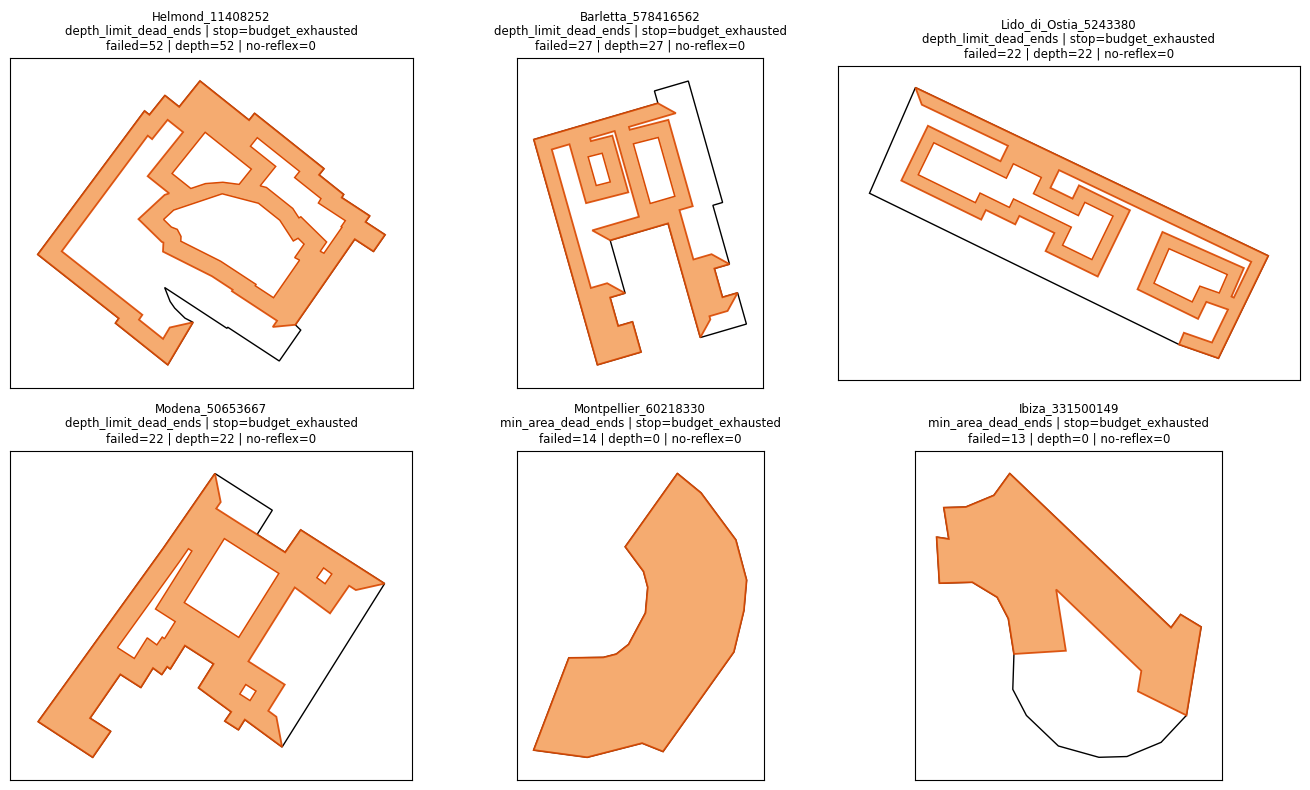

Saved failed-decomposition gallery to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/notebooks/osm_failed_decomposition_examples.pdf


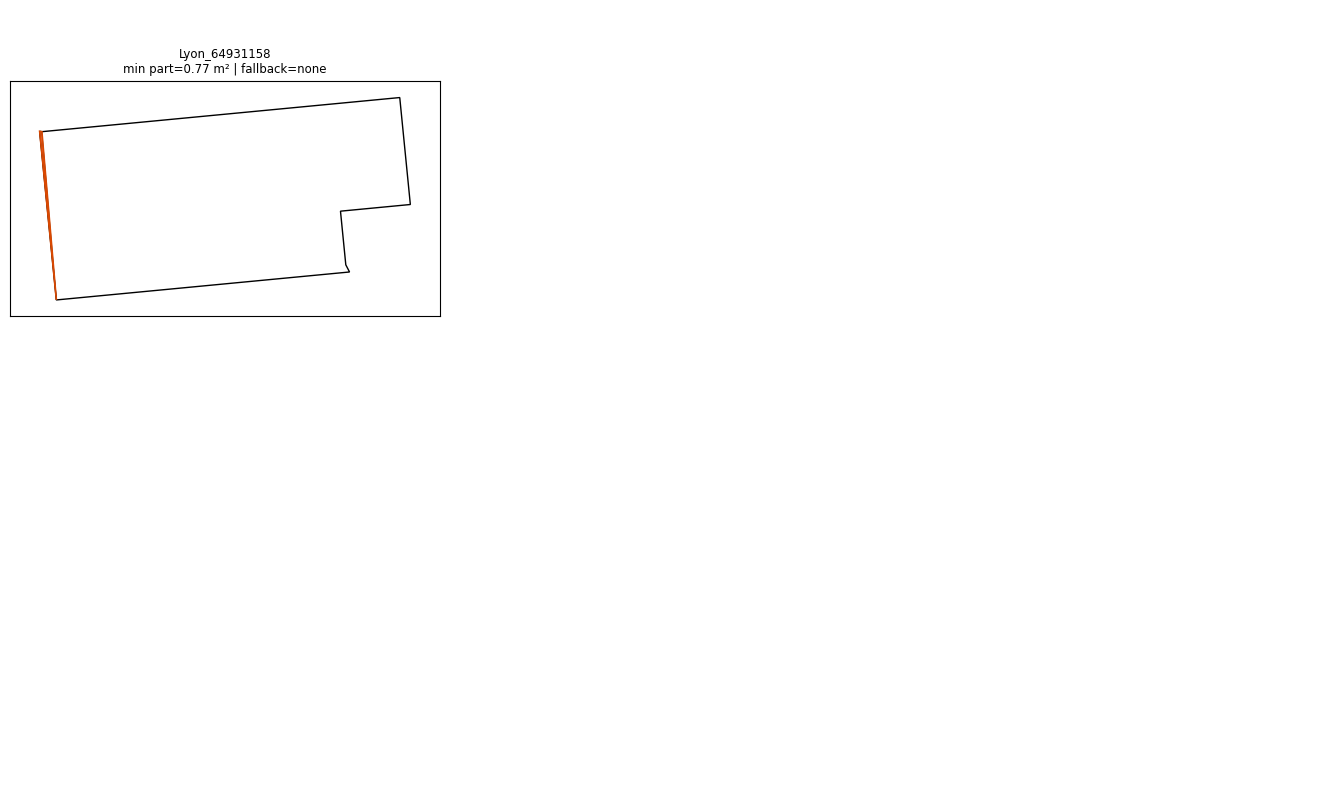

In [11]:
N_FAILURE_EXAMPLES = 6
N_SMALL_ZONE_EXAMPLES = 6


def draw_geom(ax, geom, *, facecolor='none', edgecolor='black', linewidth=0.8, alpha=1.0):
    if geom is None or getattr(geom, 'is_empty', True):
        return
    if hasattr(geom, 'geoms') and not isinstance(geom, Polygon):
        for part in geom.geoms:
            draw_geom(ax, part, facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth, alpha=alpha)
        return
    if not hasattr(geom, 'exterior'):
        return
    xs, ys = geom.exterior.xy
    ax.fill(xs, ys, facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth, alpha=alpha)
    for interior in getattr(geom, 'interiors', []):
        ixs, iys = interior.xy
        ax.fill(ixs, iys, facecolor='white', edgecolor=edgecolor, linewidth=max(0.4, linewidth * 0.8), alpha=1.0)


def setup_local_axes(ax, geom: BaseGeometry):
    minx, miny, maxx, maxy = geom.bounds
    padx = max(1.0, 0.08 * max(maxx - minx, 1.0))
    pady = max(1.0, 0.08 * max(maxy - miny, 1.0))
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])


failed_examples = failed_polygon_gdf.sort_values(
    ['failure_reason', 'n_failed_terminal_states', 'n_states_seen'],
    ascending=[True, False, False],
).head(N_FAILURE_EXAMPLES)
small_zone_examples = small_zone_polygon_gdf.sort_values(
    ['best_min_part_area_m2', 'n_states_seen'],
    ascending=[True, False],
).head(N_SMALL_ZONE_EXAMPLES)

if failed_examples.empty:
    print('No failed polygons under the current configuration.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
    axes = axes.flatten()
    for ax, (_, rec) in zip(axes, failed_examples.iterrows()):
        draw_geom(ax, rec['building_geometry'], facecolor='none', edgecolor='black', linewidth=1.0)
        draw_geom(ax, rec['geometry'], facecolor='#f4a261', edgecolor='#d94801', linewidth=1.3, alpha=0.9)
        setup_local_axes(ax, rec['building_geometry'])
        ax.set_title(
            f"{rec['sample_id']}\n{rec['failure_reason']} | stop={rec['search_terminated_by']}\n"
            f"failed={int(rec['n_failed_terminal_states'])} | depth={int(rec['n_depth_limit_dead_ends'])} | "
            f"no-reflex={int(rec['n_no_reflex_dead_ends'])}",
            fontsize=8.5,
        )
    for ax in axes[len(failed_examples):]:
        ax.axis('off')
    plt.tight_layout()
    failed_fig_path = PROJECT_ROOT / 'notebooks' / 'osm_failed_decomposition_examples.pdf'
    fig.savefig(failed_fig_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f'Saved failed-decomposition gallery to {failed_fig_path}')

if small_zone_examples.empty:
    print('No small-zone polygons under the current configuration.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
    axes = axes.flatten()
    for ax, (_, rec) in zip(axes, small_zone_examples.iterrows()):
        draw_geom(ax, rec['building_geometry'], facecolor='none', edgecolor='black', linewidth=1.0)
        best_variant_geom = rec['best_variant_geom']
        parts = []
        if best_variant_geom is not None and not getattr(best_variant_geom, 'is_empty', True):
            parts = list(best_variant_geom.geoms) if hasattr(best_variant_geom, 'geoms') else [best_variant_geom]
        for part in parts:
            area = getattr(part, 'area', 0.0)
            draw_geom(
                ax,
                part,
                facecolor='#e76f51' if area < cfg.min_area_m2 else '#8ecae6',
                edgecolor='black',
                linewidth=0.6,
                alpha=0.95,
            )
        draw_geom(ax, rec['geometry'], facecolor='none', edgecolor='#d94801', linewidth=1.2)
        setup_local_axes(ax, rec['building_geometry'])
        ax.set_title(
            f"{rec['sample_id']}\nmin part={rec['best_min_part_area_m2']:.2f} m² | fallback={rec['fallback_used'] or 'none'}",
            fontsize=8.5,
        )
    for ax in axes[len(small_zone_examples):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## Plot decomposition results
### Plot convex part-count distributions


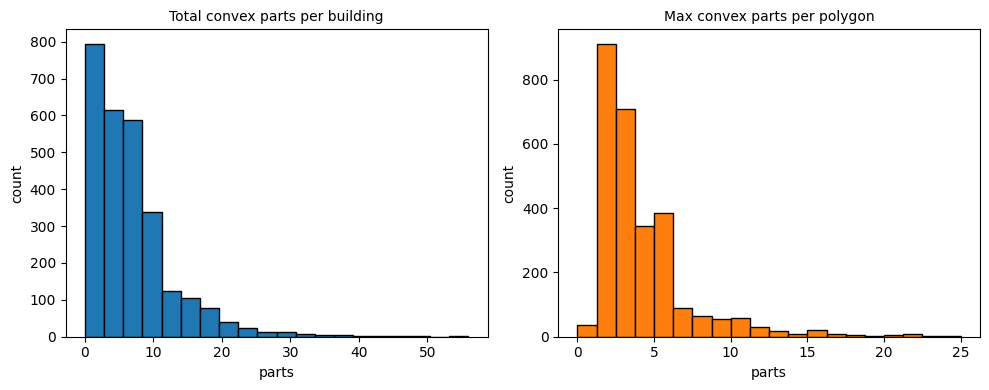

In [12]:
total_parts = buildings_convex_gdf['convex_parts_counts'].apply(lambda xs: int(sum(xs)) if isinstance(xs, list) else 0)
max_parts = buildings_convex_gdf['convex_parts_counts'].apply(lambda xs: int(max(xs)) if isinstance(xs, list) and xs else 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(total_parts, bins=20, color='#1f77b4', edgecolor='black')
axes[0].set_title('Total convex parts per building')
axes[0].set_xlabel('parts')
axes[0].set_ylabel('count')

axes[1].hist(max_parts, bins=20, color='#ff7f0e', edgecolor='black')
axes[1].set_title('Max convex parts per polygon')
axes[1].set_xlabel('parts')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()


### Plot vertex-binned success and runtime


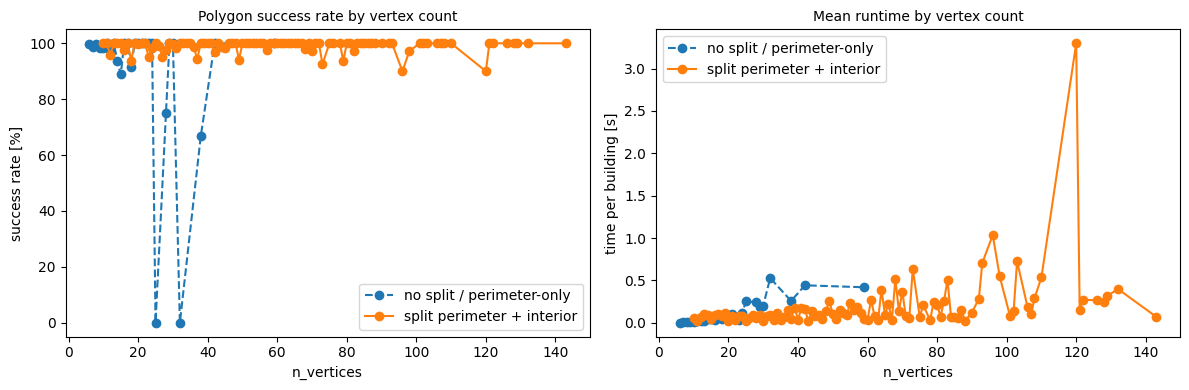

In [13]:
stats_plot_df = buildings_convex_gdf.copy()
stats_plot_df['perimeter_bool'] = stats_plot_df['perimeter'].fillna(False).astype(bool)
stats_plot_df['polygon_success_rate'] = stats_plot_df['polygon_fully_convex_flags'].apply(
    lambda flags: (sum(flags) / len(flags)) if isinstance(flags, list) and flags else np.nan
)

grouped = (
    stats_plot_df
    .groupby(['n_vertices', 'perimeter_bool'])[['polygon_success_rate', 'time_total_seconds']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for is_perimeter, linestyle, label in [(False, '--', 'no split / perimeter-only'), (True, '-', 'split perimeter + interior')]:
    sub = grouped.loc[grouped['perimeter_bool'] == is_perimeter].sort_values('n_vertices')
    if sub.empty:
        continue
    axes[0].plot(sub['n_vertices'], 100.0 * sub['polygon_success_rate'], linestyle=linestyle, marker='o', label=label)
    axes[1].plot(sub['n_vertices'], sub['time_total_seconds'], linestyle=linestyle, marker='o', label=label)

axes[0].set_title('Polygon success rate by vertex count')
axes[0].set_xlabel('n_vertices')
axes[0].set_ylabel('success rate [%]')
axes[0].legend()

axes[1].set_title('Mean runtime by vertex count')
axes[1].set_xlabel('n_vertices')
axes[1].set_ylabel('time per building [s]')
axes[1].legend()

plt.tight_layout()
plt.show()


### Plot original versus convex comparison grids


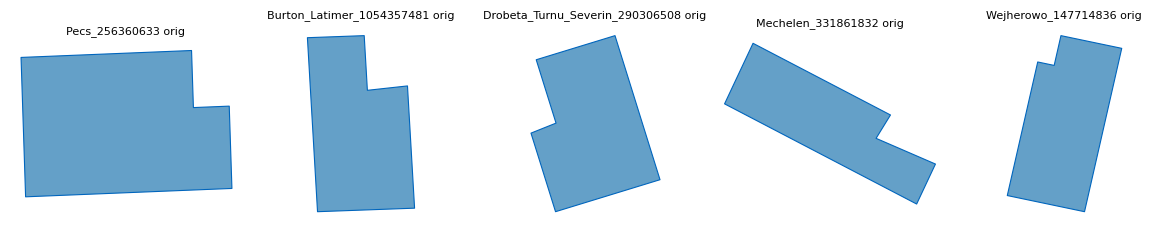

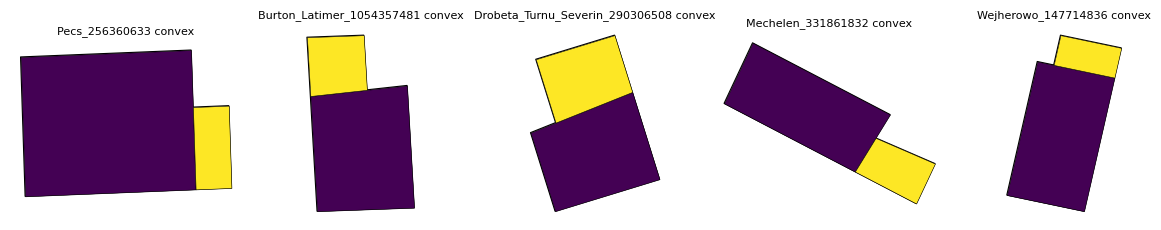

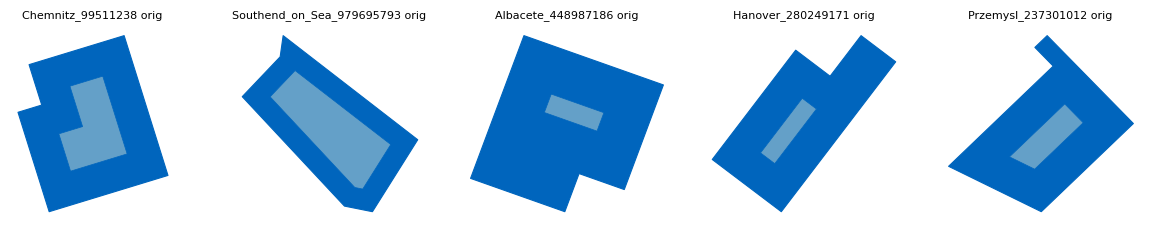

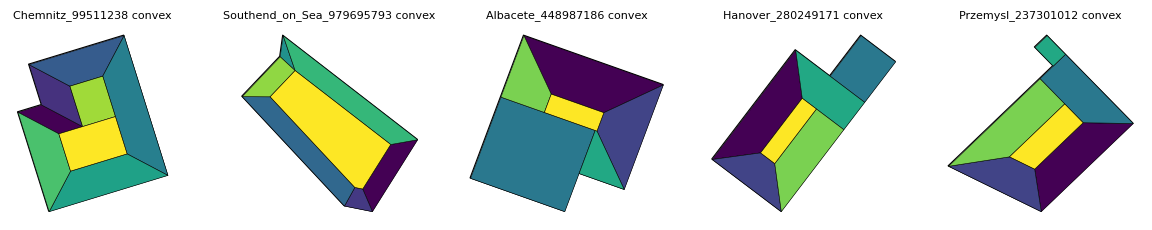

In [14]:
TUM_DARK = '#0065BD'
TUM_LIGHT = '#64A0C8'
N_COMPARE = 5


def parts_from_geom(geom: BaseGeometry | None) -> list[BaseGeometry]:
    if geom is None or getattr(geom, 'is_empty', True):
        return []
    if hasattr(geom, 'geoms'):
        return [part for part in geom.geoms if not getattr(part, 'is_empty', True)]
    return [geom]


nonperim_ids = (
    buildings_convex_gdf.loc[
        (~buildings_convex_gdf['perimeter']) & buildings_convex_gdf['building_fully_convex'],
        'sample_id',
    ]
    .dropna()
    .head(N_COMPARE)
    .tolist()
)
if len(nonperim_ids) < N_COMPARE:
    fallback = (
        buildings_convex_gdf.loc[~buildings_convex_gdf['perimeter'], 'sample_id']
        .dropna()
        .head(N_COMPARE)
        .tolist()
    )
    nonperim_ids = fallback

perim_ids_compare = (
    buildings_convex_gdf.loc[
        buildings_convex_gdf['perimeter'] & buildings_convex_gdf['building_fully_convex'],
        'sample_id',
    ]
    .dropna()
    .head(N_COMPARE)
    .tolist()
)
if len(perim_ids_compare) < N_COMPARE:
    fallback = (
        buildings_convex_gdf.loc[buildings_convex_gdf['perimeter'], 'sample_id']
        .dropna()
        .head(N_COMPARE)
        .tolist()
    )
    perim_ids_compare = fallback

nonperim = buildings_convex_gdf.loc[buildings_convex_gdf['sample_id'].isin(nonperim_ids)].copy()
nonperim_outline = gpd.GeoDataFrame(nonperim, geometry='geometry', crs=buildings_convex_gdf.crs)
nonperim_parts = nonperim.copy()
nonperim_parts['convex_parts_list'] = nonperim_parts['convex_parts_geom'].apply(parts_from_geom)

GHSL_gridplot(
    [
        {
            'name': 'nonperim_original',
            'gdf': nonperim_outline,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'geometry',
            'color': TUM_LIGHT,
            'edgecolor': TUM_DARK,
            'linewidth': 0.8,
        }
    ],
    ids=nonperim_ids,
    ncols=5,
    nrows=1,
    figsize_scale=2.4,
    title_fn=lambda sid, i: f'{sid} orig',
)
plt.show()

GHSL_gridplot(
    [
        {
            'name': 'nonperim_outline',
            'gdf': nonperim_outline,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'geometry',
            'color': 'none',
            'edgecolor': 'black',
            'linewidth': 0.8,
        },
        {
            'name': 'nonperim_convex_parts',
            'gdf': nonperim_parts,
            'role': 'main',
            'id_col': 'sample_id',
            'parts_col': 'convex_parts_list',
            'cmap': 'viridis',
            'edgecolor': 'black',
            'linewidth': 0.4,
        },
    ],
    ids=nonperim_ids,
    ncols=5,
    nrows=1,
    figsize_scale=2.4,
    title_fn=lambda sid, i: f'{sid} convex',
)
plt.show()

perim = buildings_convex_gdf.loc[buildings_convex_gdf['sample_id'].isin(perim_ids_compare)].copy()
perim_shell = gpd.GeoDataFrame(perim, geometry='perimeter_geom', crs=buildings_convex_gdf.crs)
perim_interior = gpd.GeoDataFrame(perim.loc[perim['interior_geom'].notna()].copy(), geometry='interior_geom', crs=buildings_convex_gdf.crs)
perim_parts = perim.copy()
perim_parts['convex_parts_list'] = perim_parts['convex_parts_geom'].apply(parts_from_geom)

GHSL_gridplot(
    [
        {
            'name': 'perim_shell',
            'gdf': perim_shell,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'perimeter_geom',
            'color': TUM_DARK,
            'edgecolor': TUM_DARK,
            'linewidth': 0.8,
        },
        {
            'name': 'perim_interior',
            'gdf': perim_interior,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'interior_geom',
            'color': TUM_LIGHT,
            'edgecolor': TUM_DARK,
            'linewidth': 0.5,
        },
    ],
    ids=perim_ids_compare,
    ncols=5,
    nrows=1,
    figsize_scale=2.4,
    title_fn=lambda sid, i: f'{sid} orig',
)
plt.show()

GHSL_gridplot(
    [
        {
            'name': 'perim_outline',
            'gdf': perim_shell,
            'role': 'main',
            'id_col': 'sample_id',
            'geometry_col': 'perimeter_geom',
            'color': 'none',
            'edgecolor': 'black',
            'linewidth': 0.8,
        },
        {
            'name': 'perim_convex_parts',
            'gdf': perim_parts,
            'role': 'main',
            'id_col': 'sample_id',
            'parts_col': 'convex_parts_list',
            'cmap': 'viridis',
            'edgecolor': 'black',
            'linewidth': 0.4,
        },
    ],
    ids=perim_ids_compare,
    ncols=5,
    nrows=1,
    figsize_scale=2.4,
    title_fn=lambda sid, i: f'{sid} convex',
)
plt.show()


## Final pipeline summary

### Summarize convex coverage for the OSM working set

Report the final building-level counts from the current OSM decomposition run:
1. Buildings with at least one failed polygon decomposition.
2. Buildings whose decomposed output is fully convex.
3. Buildings whose decomposed output is fully convex and all zones are at least `cfg.min_area_m2`.
4. The retained building table `buildings_convex_gdf`, which keeps the full working set and adds decomposition diagnostics.

In [15]:
n_loaded = len(subset_buildings_gdf)
n_total = len(buildings_convex_gdf)

fully_convex_flags = buildings_convex_gdf['building_fully_convex'].fillna(False).astype(bool).to_numpy(dtype=bool)
failed_flags = buildings_convex_gdf['building_decomposition_failed'].fillna(False).astype(bool).to_numpy(dtype=bool)
small_zone_flags = buildings_convex_gdf['building_has_small_zone'].fillna(False).astype(bool).to_numpy(dtype=bool)
clean_convex_flags = fully_convex_flags & ~small_zone_flags

n_failed = int(np.sum(failed_flags))
n_fully_convex = int(np.sum(fully_convex_flags))
n_clean_convex = int(np.sum(clean_convex_flags))
n_small_zone = int(np.sum(small_zone_flags))

pct_failed = 100.0 * n_failed / n_total if n_total else 0.0
pct_fully_convex = 100.0 * n_fully_convex / n_total if n_total else 0.0
pct_clean_convex = 100.0 * n_clean_convex / n_total if n_total else 0.0
pct_small_zone = 100.0 * n_small_zone / n_total if n_total else 0.0
pct_retained = 100.0 * n_total / n_loaded if n_loaded else 0.0

print('=== Dataset-level pipeline summary ===')
print(f'Loaded preselected subset: {n_loaded}')
print(f'Buildings prepared for decomposition: {n_total} / {n_loaded} ({pct_retained:.1f}%)')
print(f'Buildings with at least one failed polygon decomposition: {n_failed} / {n_total} ({pct_failed:.1f}%)')
print(f'Fully convex after H/V decomposition: {n_fully_convex} / {n_total} ({pct_fully_convex:.1f}%)')
print(
    f'Fully convex and all zones >= {cfg.min_area_m2:.1f} m^2 after decomposition: '
    f'{n_clean_convex} / {n_total} ({pct_clean_convex:.1f}%)'
)
print(f'Buildings with any zone smaller than {cfg.min_area_m2:.1f} m^2: {n_small_zone} / {n_total} ({pct_small_zone:.1f}%)')
print(
    'Retained building table with decomposition diagnostics '
    f'(no extra post-decomposition geometry filter): {n_total} / {n_loaded} ({pct_retained:.1f}%)'
)


=== Dataset-level pipeline summary ===
Loaded preselected subset: 2756
Buildings prepared for decomposition: 2756 / 2756 (100.0%)
Buildings with at least one failed polygon decomposition: 56 / 2756 (2.0%)
Fully convex after H/V decomposition: 2700 / 2756 (98.0%)
Fully convex and all zones >= 2.0 m^2 after decomposition: 2699 / 2756 (97.9%)
Buildings with any zone smaller than 2.0 m^2: 1 / 2756 (0.0%)
Retained building table with decomposition diagnostics (no extra post-decomposition geometry filter): 2756 / 2756 (100.0%)
